In [6]:
# Quality control and NDT(Non Destructive Trial)
# Probability of finding m defectives in r samples.
# Implementing Binomial and hypergeometric distributions for calculating the probabilities.

# Appraoches: 1) Direct probabilistic modelling.  
#                  using exact mathematical formulas and probabilities.
#             2) Simulating the probabilities through Monte carlo - based generative process modelling. 

#importing necessary libraries 
import numpy as np
import matplotlib.pyplot as plt

In [24]:
# Approach 1) Direct probabilistic modelling.  
#                  using exact mathematical formulas and probabilities.

# Functions for basic mathematical calculations 

# Factorial function
def factorial(n):
    result = 1
    for i in range(1,n+1):
        result*=i
    return result

# Combinations function
def combination(n,k):
    if k<0 or k> n:
        return 0
    return factorial(n)//(factorial(k)*factorial(n-k))

# Binomial Probability Mass Function
def binomial_pmf(m,r,p):
    return combination(r,m)*(p**m)*((1-p)**(r-m))

# Hypergeometric Probability Mass Function
def hypergeometric_pmf(m,N,K,r):
    num = combination(K,m)*combination(N-K,r-m)
    den = combination(N,r)
    return num/den

# probability of a specific m 
def probability_of_m(pmf, m):
    if m < 0 or m >= len(pmf):
        raise ValueError("m must be between 0 and sample size r.")
    return float(pmf[m])

In [25]:
# User input for parameters 

def get_user_parameters():
    print("Enter QC sampling parameters:")
    N = int(input("Lot size (N): "))
    K = int(input("Total defectives (K): "))
    r = int(input("Sample size (r): "))
    return N, K, r

# Computing Distributions

def compute_distributions(N,K,r):
    m_values = np.arange(0,r+1)
    p=K/N

    binom_pmf = np.array([binomial_pmf(m,r,p) for m in m_values])
    hyper_pmf = np.array([hypergeometric_pmf(m,N,K,r) for m in m_values])

    return m_values,binom_pmf,hyper_pmf

# Visualizing the distributions

def plot_distributions(m, binom_pmf, hyper_pmf):
    plt.figure(figsize=(8, 5))
    plt.plot(m, hyper_pmf, 'o-', label="Hypergeometric (exact)")
    plt.plot(m, binom_pmf, 's--', label="Binomial (approx)")
    plt.xlabel("Number of defectives in sample (m)")
    plt.ylabel("Probability")
    plt.title("QC Sampling Probability Distributions")
    plt.legend()
    plt.grid(True)
    plt.show()

# Acceptance sampling descision
def acceptance_probability(pmf,c):
    return float(pmf[:c+1].sum())


# Main Driver Code
def run_qc_probability_tool():
    print("=" * 60)
    print("QUALITY CONTROL & NDT PROBABILITY ANALYSIS TOOL")
    print("=" * 60)

    # ---- Runtime User Input ----
    try:
        N = int(input("Enter the Lot Size(N): "))
        K = int(input("Enter total defectives in lot(K): "))
        r = int(input("Enter sample size(r): "))

        if K>N:
            raise ValueError("K cannot be greater than N")
        if r>N:
            raise ValueError("Sample size cannot be greater than N")

    except ValueError as e:
        print("Input Error: ", e)
        return 

    # ---- compute Distributions ----
    m_values, binom_pmf, hyper_pmf = compute_distributions(N,K,r)

    # ---- Sanity check ----
    print("\nSanity check:")
    print("Sum of Binomial PMF       :", round(binom_pmf.sum(), 6))
    print("Sum of Hypergeometric PMF:", round(hyper_pmf.sum(), 6))

    # ---- Plot Distributions ----
    plot_distributions(m_values, binom_pmf, hyper_pmf)

    # ---- Acceptance sampling ----
    try:
        c = int(input("Enter acceptance number: "))
        if c < 0 or c > r:
            raise ValueError("c must be between 0 and r")

    except ValueError as e:
        print("Input Error:", e)
        return

    P_accept_binom = acceptance_probability(binom_pmf, c)
    P_accept_hyper = acceptance_probability(hyper_pmf, c)

    print("\nAcceptance Sampling Results")
    print("-" * 40)
    print(f"P(Accept | Binomial)       = {float(P_accept_binom):.4f}")
    print(f"P(Accept | Hypergeometric) = {float(P_accept_hyper):.4f}")

    print("\nInterpretation:")
    print("• Hypergeometric = exact finite-lot sampling")
    print("• Binomial       = independent-trial approximation")
    print("=" * 60)

    # --- Query probability of a specific m ---
    try:
        m_query = int(input("\nEnter specific number of defectives to query (m): "))
    except ValueError:
        print("Input Error: m must be an integer.")
        return

    try:
        P_m_binom = probability_of_m(binom_pmf, m_query)
        P_m_hyper = probability_of_m(hyper_pmf, m_query)
    except ValueError as e:
        print("Input Error:", e)
        return

    print("\nProbability of observing exactly m defectives")
    print("-" * 40)
    print(f"P(M = {m_query} | Binomial)       = {P_m_binom:.6f}")
    print(f"P(M = {m_query} | Hypergeometric) = {P_m_hyper:.6f}")

QUALITY CONTROL & NDT PROBABILITY ANALYSIS TOOL


Enter the Lot Size(N):  10000
Enter total defectives in lot(K):  200
Enter sample size(r):  100



Sanity check:
Sum of Binomial PMF       : 1.0
Sum of Hypergeometric PMF: 1.0


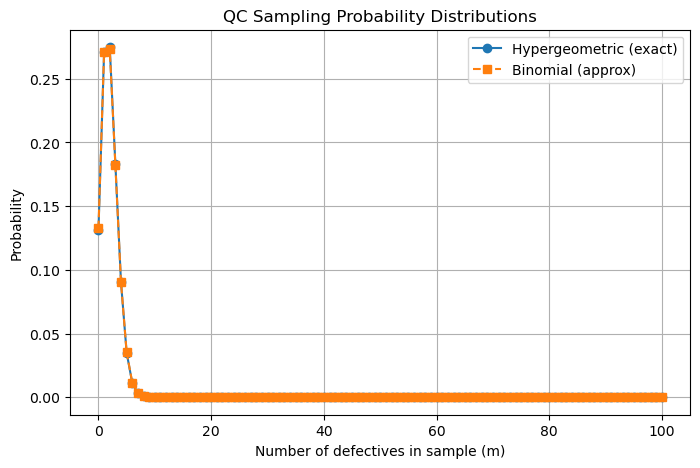

Enter acceptance number:  5



Acceptance Sampling Results
----------------------------------------
P(Accept | Binomial)       = 0.9845
P(Accept | Hypergeometric) = 0.9850

Interpretation:
• Hypergeometric = exact finite-lot sampling
• Binomial       = independent-trial approximation



Enter specific number of defectives to query (m):  30



Probability of observing exactly m defectives
----------------------------------------
P(M = 30 | Binomial)       = 0.000000
P(M = 30 | Hypergeometric) = 0.000000


In [26]:
run_qc_probability_tool()

In [32]:
# Approach 2) Simulating the probabilities through Monte carlo - based generative process modelling. 
# steps of this approach 
#       The lot is a finite list
#       Exactly K items are defective
#       We randomly sample r items without replacement
#       Count how many defectives we see
#       Repeat many times

# build the lot 
def build_lot(N,K):
    # create a finite production lot, 1 = defective , 0 = good
    lot = np.array([1]*K + [0]*(N-K))
    return lot

# one inspection experiment
def inspect_lot_once(lot,r):
    # performing one QC inspection by sampling r items without replacement and counting defectives.
    sample = np.random.choice(lot, size = r, replace = False)
    return sample.sum()

# Repeat the experiment multiple times(Monte Carlo)
def monte_carlo_hypergeometric(N,K,r,trials = 10000):
    # Monte carlo simulation of hypergeormetric sampling
    lot = build_lot(N,K)
    counts = []

    for i in range(trials):
        m = inspect_lot_once(lot,r)
        counts.append(m)

    return np.array(counts)

# Emperical PMF from simulation 
def emperical_pmf(counts,r):
    # Convert Monte Carlo counts into a probability mass function.
    pmf = np.zeros (r+1)
    for m in counts:
        pmf[m]+=1
    return pmf/len(counts)

# Monte Carlo simulation for Bernouli model

# One Bernouli experiment
def bernouli_trial(p):
    # One Bernoulli trial. Returns 1 (defective) or 0 (good).
    return 1 if np.random.rand() < p else 0

# one Binomial experiment 
def binomial_experiment(r,p):
    # Perform r independent Bernoulli trials. 
    return sum(bernouli_trial(p) for _ in range (r))

# Monte Carlo repitition for binomial experiment
def monte_carlo_binomial(r,p,trials = 10000):
    # Monte Carlo simulation of binomial sampling.
    counts = []

    for _ in range(trials):
        m = binomial_experiment(r,p)
        counts.append(m)

    return np.array(counts)

def get_qc_parameters():
    try:
        print("\nEnter QC sampling parameters:")
        N = int(input("Lot size (N): "))
        K = int(input("Total defectives in lot (K): "))
        r = int(input("Sample size (r): "))

        if N <= 0:
            raise ValueError("N must be positive.")
        if K < 0 or K > N:
            raise ValueError("K must satisfy 0 ≤ K ≤ N.")
        if r <= 0 or r > N:
            raise ValueError("r must satisfy 1 ≤ r ≤ N.")

        return N, K, r

    except ValueError as e:
        print("Input Error:", e)
        return None


In [36]:
# Driver function

def run_qc_with_simulation():
    print("=" * 60)
    print("QC & NDT PROBABILITY + MONTE CARLO SIMULATOR")
    print("=" * 60)

    # --- Get parameters ---
    params = get_qc_parameters()
    if params is None:
        return

    N, K, r = params
    p = K / N

    # --- Analytical distributions ---
    m_values = np.arange(0, r + 1)

    binom_pmf = np.array([binomial_pmf(m, r, p) for m in m_values])
    hyper_pmf = np.array([hypergeometric_pmf(m, N, K, r) for m in m_values])

    # --- Monte Carlo simulations ---
    trials = int(input("\nNumber of Monte Carlo trials: "))

    hyper_counts = monte_carlo_hypergeometric(N, K, r, trials)
    pmf_hyper_mc = emperical_pmf(hyper_counts, r)

    binom_counts = monte_carlo_binomial(r, p, trials)
    pmf_binom_mc = emperical_pmf(binom_counts, r)

    # --- Plot comparison ---
    plt.figure(figsize=(9, 5))

    plt.plot(m_values, hyper_pmf, 'o-', label="Hypergeometric (theory)")
    plt.plot(m_values, pmf_hyper_mc, 'x--', label="Hypergeometric (MC)")

    plt.plot(m_values, binom_pmf, 's-', label="Binomial (theory)")
    plt.plot(m_values, pmf_binom_mc, '+--', label="Binomial (MC)")

    plt.xlabel("Number of defectives (m)")
    plt.ylabel("Probability")
    plt.title("QC Sampling: Theory vs Monte Carlo Simulation")
    plt.legend()
    plt.grid(True)
    plt.show()

    # --- Query specific m ---
    try:
        m_query = int(input("\nQuery probability for specific m: "))
        if m_query < 0 or m_query > r:
            raise ValueError
    except ValueError:
        print("Invalid m value.")
        return

    print("\nP(M = m)")
    print("-" * 30)
    print(f"Binomial       : {binom_pmf[m_query]:.6f}")
    print(f"Hypergeometric : {hyper_pmf[m_query]:.6f}")
    print(f"Binomial (MC)  : {pmf_binom_mc[m_query]:.6f}")
    print(f"Hyper (MC)     : {pmf_hyper_mc[m_query]:.6f}")

    # --- Acceptance sampling ---
    try:
        c = int(input("\nEnter acceptance number (c): "))
        if c < 0 or c > r:
            raise ValueError
    except ValueError:
        print("Invalid acceptance number.")
        return

    P_accept_binom = float(binom_pmf[:c + 1].sum())
    P_accept_hyper = float(hyper_pmf[:c + 1].sum())

    print("\nAcceptance Sampling Results")
    print("-" * 40)
    print(f"P(Accept | Binomial)       = {P_accept_binom:.4f}")
    print(f"P(Accept | Hypergeometric) = {P_accept_hyper:.4f}")

    print("=" * 60)


QC & NDT PROBABILITY + MONTE CARLO SIMULATOR

Enter QC sampling parameters:


Lot size (N):  1000
Total defectives in lot (K):  200
Sample size (r):  100

Number of Monte Carlo trials:  20000


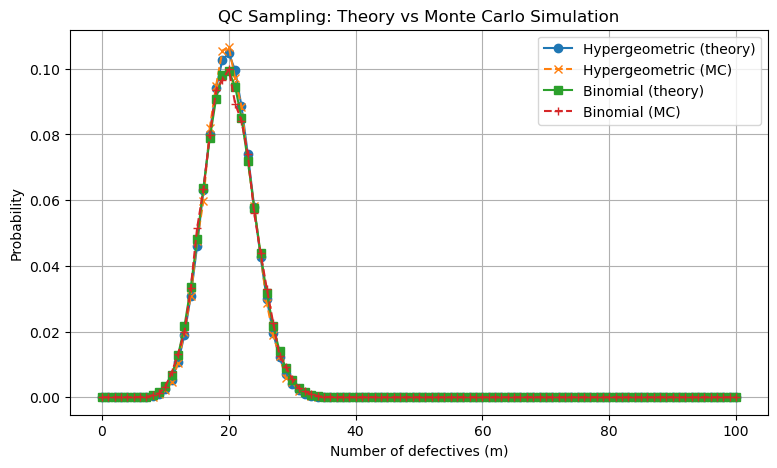


Query probability for specific m:  30



P(M = m)
------------------------------
Binomial       : 0.005190
Hypergeometric : 0.003930
Binomial (MC)  : 0.005500
Hyper (MC)     : 0.004650



Enter acceptance number (c):  5



Acceptance Sampling Results
----------------------------------------
P(Accept | Binomial)       = 0.0000
P(Accept | Hypergeometric) = 0.0000


In [37]:
run_qc_with_simulation()
